# Fase 4 — Clasificador BiLSTM con Embeddings FastText

**Proyecto:** Grafo de conocimiento UAM-Azcapotzalco — Clasificación de tópicos de artículos científicos  
**Modelo:** BiLSTM bidireccional con embeddings FastText entrenados en la Fase 3  
**Entrenamiento:** arXiv Top-10 CS (corpus aumentado de la Fase 2)  
**Evaluación:** Validación interna arXiv (20%) + Transferencia pura sobre 733 artículos UAM-A  

---

## Celda 1 — Imports y Configuración

In [1]:
import torch, gensim, transformers, pandas, numpy

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.version.cuda}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"gensim      : {gensim.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"pandas      : {pandas.__version__}")

PyTorch     : 2.11.0+cu128
CUDA        : 12.8
GPU         : NVIDIA GeForce RTX 5090
VRAM        : 34.2 GB
gensim      : 4.4.0
transformers: 5.4.0
pandas      : 2.3.3


In [2]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import os
import re
import json
import time
import random
import pickle
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")


#  Ciencia de datos 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  PyTorch 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

#  Scikit-learn 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

#  Utilidades 
from tqdm.notebook import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE DE CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────

# Rutas de archivos
AUGMENTED_PATH  = r"D:\Aaron\arxiv_cs_top10_augmented.parquet"    #  Fase 2
EMBEDDING_PATH  = r"D:\Aaron\embedding_matrix_01_04_2026_09_39_20_.npy "               #  Fase 3
VOCAB_PATH      = r"D:\Aaron\vocab2idx_01_04_2026_09_39_20_.pkl"                      #  Fase 3
UAM_PATH        = r"C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\Articulos.csv"              # dataset de transferencia

# --- Salidas ---
now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

MODEL_SAVE_PATH = r"D:\Aaron\Fase 4 BiLSTM\bilstm_best_"  + date_time + ".pt"                     # modelo a guardar

# Hiperparámetros
MAX_LEN       = 256    # tokens máximos por secuencia (truncado o padding)
BATCH_SIZE    = 64
HIDDEN_SIZE   = 256    # unidades LSTM por dirección
NUM_LAYERS    = 2      # capas LSTM apiladas
DROPOUT       = 0.3
LEARNING_RATE = 1e-3
EPOCHS        = 20
PATIENCE      = 5      # épocas sin mejora para early stopping
RANDOM_SEED   = 42
NUM_CLASSES   = 10
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── Fijar todas las semillas aleatorias ────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False   # reproducibilidad > velocidad

set_seed(RANDOM_SEED)

print(f"Dispositivo de cómputo : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU                    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch                : {torch.__version__}")

Dispositivo de cómputo : cuda
GPU                    : NVIDIA GeForce RTX 5090
VRAM total             : 34.2 GB
PyTorch                : 2.11.0+cu128


## Celda 2 — Carga de Artefactos de la Fase 3

In [3]:
#  Cargar embedding matrix 
print("Cargando embedding_matrix.npy ...")
embedding_matrix = np.load(EMBEDDING_PATH)          # shape: (147009, 300), float32

VOCAB_SIZE, EMBEDDING_DIM = embedding_matrix.shape
print(f"  → Forma de la matriz  : {embedding_matrix.shape}")
print(f"  → Tipo de dato        : {embedding_matrix.dtype}")
assert VOCAB_SIZE == 147_009, f"Vocabulario inesperado: {VOCAB_SIZE}"
assert EMBEDDING_DIM == 300,  f"Dimensión inesperada: {EMBEDDING_DIM}"
print("   Verificación de dimensiones correcta")

#  Cargar vocab2idx 
print("\nCargando vocab2idx.pkl ...")
with open(VOCAB_PATH, "rb") as f:
    vocab2idx = pickle.load(f)

print(f"  → Tokens en vocabulario : {len(vocab2idx):,}")
print(f"  → Índice <PAD>          : {vocab2idx.get('<PAD>', 0)}")
print(f"  → Índice <UNK>          : {vocab2idx.get('<UNK>', 1)}")

#  Verificar compatibilidad con nn.Embedding 
_test_emb = nn.Embedding.from_pretrained(
    torch.tensor(embedding_matrix[:10], dtype=torch.float32),
    freeze=False, padding_idx=0
)
del _test_emb

print("   Compatible con nn.Embedding.from_pretrained()")

def clean_and_tokenize(text: str) -> list[str]:
    """Limpieza y tokenización consistente con la Fase 3.
    
    Pasos:
      1. Minúsculas
      2. Eliminar referencias numéricas tipo [1], (2019)
      3. Eliminar caracteres no ASCII y puntuación, conservar hifens internos
      4. Colapsar espacios múltiples
      5. Split por espacios → lista de tokens (≥ 2 caracteres)
    """
    if not isinstance(text, str) or not text.strip():
        return []
    text = text.lower()
    text = re.sub(r"\[\d+\]|\(\d{4}\)", " ", text)  # referencias numéricas
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)        # no-ASCII / puntuación
    text = re.sub(r"(?<![a-z])\-|\-(?![a-z])", " ", text)  # hifens no internos
    text = re.sub(r"\s+", " ", text).strip()
    return [t for t in text.split() if len(t) >= 2]

#  Conversión de texto → secuencia de índices con padding 
PAD_IDX = 0
UNK_IDX = 1

def text_to_sequence(text: str, max_len: int = MAX_LEN) -> list[int]:
    """Convierte texto a lista de enteros de longitud max_len.
    
    - Tokens en vocab  → su índice
    - Tokens <UNK>     → índice 1
    - Relleno (<PAD>)  → índice 0 (post-padding)
    - Truncado         → se conservan los primeros max_len tokens
    """
    tokens = clean_and_tokenize(text)
    indices = [vocab2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    # Post-padding hasta max_len
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

# Prueba rápida
_sample = "Deep learning methods have shown strong performance on image classification tasks."
_seq    = text_to_sequence(_sample)
assert len(_seq) == MAX_LEN, "La secuencia no tiene MAX_LEN elementos."
print(f"\n   text_to_sequence() verificada — longitud de salida: {len(_seq)}")

Cargando embedding_matrix.npy ...
  → Forma de la matriz  : (147009, 300)
  → Tipo de dato        : float32
   Verificación de dimensiones correcta

Cargando vocab2idx.pkl ...
  → Tokens en vocabulario : 147,009
  → Índice <PAD>          : 0
  → Índice <UNK>          : 1
   Compatible con nn.Embedding.from_pretrained()

   text_to_sequence() verificada — longitud de salida: 256


## Celda 3 — Carga y Preparación del Corpus arXiv

In [4]:
from tqdm.auto import tqdm
# Cargar corpus aumentado 
print(f"Cargando {AUGMENTED_PATH} ...")
df = pd.read_parquet(AUGMENTED_PATH)
print(f"  → Filas totales  : {len(df):,}")
print(f"  → Columnas       : {list(df.columns)}")

# Columna de texto: se asume 'texto_limpio'; ajustar si difiere
TEXT_COL  = "texto_limpio"
LABEL_COL = "cs_primary"

assert TEXT_COL  in df.columns, f"Columna '{TEXT_COL}' no encontrada"
assert LABEL_COL in df.columns, f"Columna '{LABEL_COL}' no encontrada"

# Eliminar nulos
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print(f"  → Tras eliminar nulos : {len(df):,}")

#  Mapeo de etiquetas 
LABEL_ORDER = sorted(df[LABEL_COL].unique().tolist())  # orden alfabético estable
label2idx   = {lbl: idx for idx, lbl in enumerate(LABEL_ORDER)}
idx2label   = {idx: lbl for lbl, idx in label2idx.items()}

print(f"\nClases ({len(label2idx)}) y sus índices:")
for lbl, idx in label2idx.items():
    print(f"  {idx:2d}  {lbl}")

#  Pesos de clase: peso_i = N_total / (K × N_i) 
N_total = len(df)
K       = len(label2idx)
class_counts  = df[LABEL_COL].value_counts()
class_weights = torch.tensor(
    [N_total / (K * class_counts[lbl]) for lbl in LABEL_ORDER],
    dtype=torch.float32
)
print("\nPesos de clase (para CrossEntropyLoss):")
for lbl, w in zip(LABEL_ORDER, class_weights.tolist()):
    print(f"  {lbl:8s}  {w:.4f}   (N={class_counts[lbl]:,})")

#  Tokenización y conversión a secuencias 
print("\nTokenizando y convirtiendo abstracts a secuencias de índices...")
# Calcular longitudes ANTES del truncado para estadísticas
raw_lengths = df[TEXT_COL].apply(
    lambda t: len(clean_and_tokenize(t)) if isinstance(t, str) else 0
)
print(f"  Longitud promedio : {raw_lengths.mean():.1f} tokens")
print(f"  Longitud mínima   : {raw_lengths.min()} tokens")
print(f"  Longitud máxima   : {raw_lengths.max()} tokens")
print(f"  Percentil 95      : {raw_lengths.quantile(0.95):.0f} tokens")
print(f"  Cobertura MAX_LEN : {(raw_lengths <= MAX_LEN).mean()*100:.1f}% de secuencias caben sin truncado")

sequences = [
    text_to_sequence(text)
    for text in tqdm(df[TEXT_COL], desc="Convirtiendo a índices")
]
labels = [label2idx[lbl] for lbl in df[LABEL_COL]]

print(f"\n   {len(sequences):,} secuencias listas")

Cargando D:\Aaron\arxiv_cs_top10_augmented.parquet ...
  → Filas totales  : 713,063
  → Columnas       : ['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id']
  → Tras eliminar nulos : 713,063

Clases (10) y sus índices:
   0  cs.AI
   1  cs.CL
   2  cs.CR
   3  cs.CV
   4  cs.DS
   5  cs.IT
   6  cs.LG
   7  cs.NA
   8  cs.RO
   9  cs.SY

Pesos de clase (para CrossEntropyLoss):
  cs.AI     1.4634   (N=48,726)
  cs.CL     0.8840   (N=80,661)
  cs.CR     1.5647   (N=45,571)
  cs.CV     0.4494   (N=158,664)
  cs.DS     1.8266   (N=39,038)
  cs.IT     1.4581   (N=48,902)
  cs.LG     0.4361   (N=163,511)
  cs.NA     1.7811   (N=40,034)
  cs.RO     1.5353   (N=46,445)
  cs.SY     1.7178   (N=41,511)

Tokenizando y convirtiendo abstracts a secuencias de índices...
  Longitud promedio : 157.8 tokens
  Longitud mínima   : 0 tokens
  Longitud máxima   : 563 tokens
  Percentil 95      : 240 tokens
  Cobertura MAX_LEN : 97.9% de secuencias caben sin truncado


Convirtiendo a índices:   0%|          | 0/713063 [00:00<?, ?it/s]


   713,063 secuencias listas


## Celda 4 — Dataset y DataLoaders

In [5]:
class ArxivDataset(Dataset):
    """Dataset para secuencias de índices de tokens y etiquetas enteras."""

    def __init__(self, seqs: list[list[int]], labels: list[int]):
        # Convertir directamente a tensores para evitar copia por lote
        self.X = torch.tensor(seqs,   dtype=torch.long).clone()
        self.y = torch.tensor(labels, dtype=torch.long).clone()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

# Convertir a numpy arrays para train_test_split
sequences_arr = np.array(sequences, dtype=object)
labels_arr    = np.array(labels,    dtype=np.int32)

# Split 70 / 15 / 15 estratificado
# Paso 1: separar train (70%) del resto (30%)
seq_train, seq_temp, lbl_train, lbl_temp = train_test_split(
    sequences_arr, labels_arr,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=labels_arr
)

# Paso 2: dividir el 30% restante en val (15%) y test (15%)
# test_size=0.5 porque 0.5 × 30% = 15% del total
seq_val, seq_test, lbl_val, lbl_test = train_test_split(
    seq_temp, lbl_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=lbl_temp
)

print(f"Partición del corpus:")
print(f"  Train      : {len(seq_train):,} muestras  (~70%)")
print(f"  Validación : {len(seq_val):,} muestras  (~15%)")
print(f"  Test       : {len(seq_test):,} muestras  (~15%)")

train_ds = ArxivDataset(seq_train.tolist(), lbl_train.tolist())
val_ds   = ArxivDataset(seq_val.tolist(),   lbl_val.tolist())
test_ds  = ArxivDataset(seq_test.tolist(),  lbl_test.tolist())

# DataLoaders 
# num_workers=0 en Windows para evitar errores de multiprocessing
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=0
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=0
)
test_loader  = DataLoader(
    test_ds,  
    batch_size=BATCH_SIZE, 
    shuffle=False,   
    pin_memory=(DEVICE.type == "cuda"), 
    num_workers=0
)



print(f"\nDataLoaders creados:")
print(f"  Lotes train      : {len(train_loader):,}")
print(f"  Lotes validación : {len(val_loader):,}")
print(f"  Lotes test       : {len(test_loader):,}")
print(f"  pin_memory       : {DEVICE.type == 'cuda'}")

Partición del corpus:
  Train      : 499,144 muestras  (~70%)
  Validación : 106,959 muestras  (~15%)
  Test       : 106,960 muestras  (~15%)

DataLoaders creados:
  Lotes train      : 7,800
  Lotes validación : 1,672
  Lotes test       : 1,672
  pin_memory       : True


## Celda 5 — Arquitectura BiLSTM

In [6]:
class BiLSTMClassifier(nn.Module):
    """Clasificador BiLSTM con embeddings FastText pre-entrenados.

    Arquitectura:
      Embedding (300d, fine-tunable) → Dropout → BiLSTM (2 capas) 
      → Pooling estados finales (fw + bw) → LayerNorm → Linear (10 clases)
    """

    def __init__(
        self,
        embedding_matrix: np.ndarray,
        hidden_size: int = HIDDEN_SIZE,
        num_layers: int  = NUM_LAYERS,
        num_classes: int = NUM_CLASSES,
        dropout: float   = DROPOUT,
        padding_idx: int = PAD_IDX
    ):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape

        #  Capa de embedding 
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),  # copia real, sin vínculo numpy
            freeze=False,
            padding_idx=padding_idx
        )

        #  Dropout post-embedding 
        self.emb_dropout = nn.Dropout(p=dropout)

        #  BiLSTM 
        # dropout interno de LSTM solo actúa ENTRE capas (num_layers > 1)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Normalización sobre representación concatenada 
        # El estado final concatena forward[-1] + backward[-1] → hidden_size * 2
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        #  Dropout pre-clasificación 
        self.cls_dropout = nn.Dropout(p=dropout)

        #  Capa de clasificación final 
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: LongTensor de forma (batch, seq_len) con índices de tokens
        Returns:
            logits: FloatTensor de forma (batch, num_classes)
        """
        # (batch, seq_len) → (batch, seq_len, emb_dim)
        emb = self.emb_dropout(self.embedding(x))

        # LSTM: output (batch, seq, hidden*2), hidden (num_layers*2, batch, hidden)
        _, (hidden, _) = self.lstm(emb)

        # hidden shape: (num_layers * 2, batch, hidden_size)
        # Extraer estados finales de la última capa: forward → [-2], backward → [-1]
        # Concatenar a lo largo de la dimensión oculta
        last_forward  = hidden[-2]   # (batch, hidden_size)
        last_backward = hidden[-1]   # (batch, hidden_size)
        pooled = torch.cat([last_forward, last_backward], dim=1)  # (batch, hidden*2)

        # Normalización + dropout
        pooled = self.layer_norm(pooled)
        pooled = self.cls_dropout(pooled)

        # Logits
        return self.classifier(pooled)  # (batch, num_classes)


model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Arquitectura BiLSTM:")
print(model)
print(f"\nParámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}")

# Prueba de forward pass con lote sintético
with torch.no_grad():
    _x_dummy = torch.zeros(2, MAX_LEN, dtype=torch.long).to(DEVICE)
    _out     = model(_x_dummy)
    assert _out.shape == (2, NUM_CLASSES), f"Forma inesperada: {_out.shape}"
print("\n   Forward pass verificado — salida: (batch=2, num_classes=10)")

Arquitectura BiLSTM:
BiLSTMClassifier(
  (embedding): Embedding(147009, 300, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (cls_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=10, bias=True)
)

Parámetros totales     : 46,828,598
Parámetros entrenables : 46,828,598

   Forward pass verificado — salida: (batch=2, num_classes=10)


## Celda 6 — Configuración del Entrenamiento

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

#  Función de pérdida con pesos de clase 
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

#  Scheduler: reducir LR si Macro F1 de val no mejora 
# mode='max' porque optimizamos F1 (mayor = mejor)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

#  GradScaler para mixed precision (AMP) 
scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))


#  Estado de early stopping 
best_val_f1    = -1.0
epochs_no_imp  = 0       # épocas consecutivas sin mejora
best_epoch     = 0

#  Historial de métricas 
history = {
    "train_loss" : [],
    "val_loss"   : [],
    "val_f1"     : [],
    "lr"         : []
}

print("Configuración del entrenamiento:")
print(f"  Optimizador  : Adam  (lr={LEARNING_RATE})")
print(f"  Pérdida      : CrossEntropyLoss con pesos de clase")
print(f"  Scheduler    : ReduceLROnPlateau (mode=max, patience=2, factor=0.5)")
print(f"  Mixed prec.  : {'Habilitada (AMP)' if DEVICE.type == 'cuda' else 'Deshabilitada (CPU)'}")
print(f"  Early stop.  : patience={PATIENCE} épocas (basado en Macro F1 val)")

Configuración del entrenamiento:
  Optimizador  : Adam  (lr=0.001)
  Pérdida      : CrossEntropyLoss con pesos de clase
  Scheduler    : ReduceLROnPlateau (mode=max, patience=2, factor=0.5)
  Mixed prec.  : Habilitada (AMP)
  Early stop.  : patience=5 épocas (basado en Macro F1 val)


## Celda 7 — Loop de Entrenamiento

VRAM antes del entrenamiento:
  Asignada  : 0.20 GB
  Reservada : 0.28 GB

Iniciando entrenamiento — 20 épocas máx., early stopping patience=5


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 01/20  | train_loss=0.6181  | val_loss=0.4955  | val_macro_f1=0.8074  | lr=1.00e-03  | 639s
           Nuevo mejor modelo guardado (Macro F1=0.8074)


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 07/20  | train_loss=0.1249  | val_loss=0.8679  | val_macro_f1=0.8083  | lr=5.00e-04  | 667s
          – Sin mejora (4/5)


  Train:   0%|          | 0/7800 [00:00<?, ?it/s]

  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]

Época 08/20  | train_loss=0.1010  | val_loss=1.0113  | val_macro_f1=0.8086  | lr=5.00e-04  | 668s
          – Sin mejora (5/5)

  Early stopping activado en época 8 (mejor época: 3)
Entrenamiento completado en 85.8 min
Mejor Macro F1 validación : 0.8193  (época 3)

VRAM después del entrenamiento:
  Asignada  : 0.78 GB
  Reservada : 1.87 GB
  Pico      : 1.15 GB


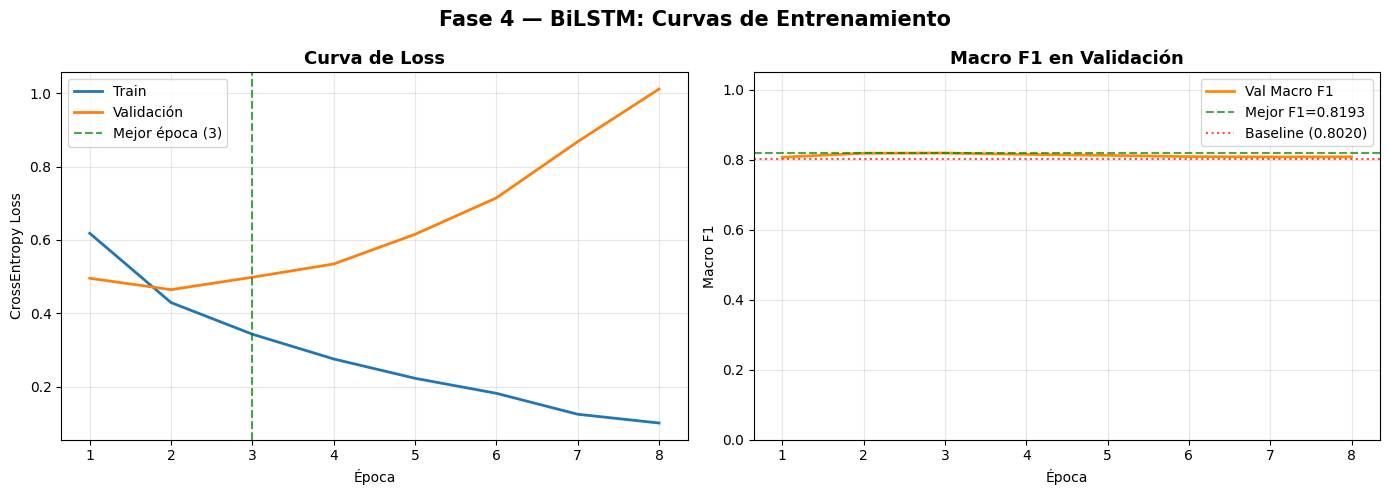

   Gráfica guardada: bilstm_training_curves.png


In [8]:
#  Funciones auxiliares 

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Ejecuta una época de entrenamiento con AMP."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in tqdm(loader, desc="  Train", leave=False):
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # más eficiente que zero_grad()

        with autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """Evaluación sobre un loader; retorna (loss, macro_f1, predicciones, etiquetas)."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc="  Val  ", leave=False):
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            preds  = torch.argmax(logits, dim=1)

            total_loss += loss.item() * len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels


#  Reportar VRAM antes del entrenamiento 
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    print(f"VRAM antes del entrenamiento:")
    print(f"  Asignada  : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"  Reservada : {torch.cuda.memory_reserved()  / 1e9:.2f} GB")

# ─────────────────────────────────────────────────────────────────────────────
# LOOP PRINCIPAL DE ENTRENAMIENTO
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nIniciando entrenamiento — {EPOCHS} épocas máx., early stopping patience={PATIENCE}")
print("=" * 80)

t_total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]["lr"]
    t_epoch    = time.time() - t_epoch_start

    # Guardar historial
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(
        f"Época {epoch:02d}/{EPOCHS}  "
        f"| train_loss={train_loss:.4f}  "
        f"| val_loss={val_loss:.4f}  "
        f"| val_macro_f1={val_f1:.4f}  "
        f"| lr={current_lr:.2e}  "
        f"| {t_epoch:.0f}s"
    )

    # ── Checkpoint del mejor modelo ──────────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"           Nuevo mejor modelo guardado (Macro F1={best_val_f1:.4f})")
    else:
        epochs_no_imp += 1
        print(f"          – Sin mejora ({epochs_no_imp}/{PATIENCE})")

    #  Ajuste de LR basado en Macro F1 
    scheduler.step(val_f1)

    #  Early stopping 
    if epochs_no_imp >= PATIENCE:
        print(f"\n  Early stopping activado en época {epoch} (mejor época: {best_epoch})")
        break

t_total = time.time() - t_total_start
print("=" * 80)
print(f"Entrenamiento completado en {t_total/60:.1f} min")
print(f"Mejor Macro F1 validación : {best_val_f1:.4f}  (época {best_epoch})")

if DEVICE.type == "cuda":
    print(f"\nVRAM después del entrenamiento:")
    print(f"  Asignada  : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"  Reservada : {torch.cuda.memory_reserved()  / 1e9:.2f} GB")
    print(f"  Pico      : {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

#  Curvas de aprendizaje 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train",      linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Validación", linewidth=2)
axes[0].axvline(best_epoch, color="green", linestyle="--", alpha=0.7, label=f"Mejor época ({best_epoch})")
axes[0].set_title("Curva de Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Macro F1
axes[1].plot(epochs_range, history["val_f1"], color="darkorange", linewidth=2, label="Val Macro F1")
axes[1].axhline(best_val_f1, color="green", linestyle="--", alpha=0.7, label=f"Mejor F1={best_val_f1:.4f}")
axes[1].axhline(0.8020,       color="red",   linestyle=":",  alpha=0.7, label="Baseline (0.8020)")
axes[1].set_title("Macro F1 en Validación", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Fase 4 — BiLSTM: Curvas de Entrenamiento", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("bilstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("   Gráfica guardada: bilstm_training_curves.png")

## Celda 8 — Evaluación Interna sobre Validación arXiv

Cargando mejor modelo desde 'D:\Aaron\Fase 4 BiLSTM\bilstm_best_01_04_2026_21_49_55.pt' ...
   Modelo cargado


  Val  :   0%|          | 0/1672 [00:00<?, ?it/s]


  EVALUACIÓN — TEST INTERNO arXiv (15%)
  Val Loss    : 0.4969
  Macro F1    : 0.8215

Classification Report por clase:
              precision    recall  f1-score   support

       cs.AI     0.5055    0.5366    0.5206      7309
       cs.CL     0.8053    0.9068    0.8530     12099
       cs.CR     0.8382    0.8995    0.8677      6835
       cs.CV     0.8994    0.8821    0.8906     23800
       cs.DS     0.8116    0.9418    0.8719      5856
       cs.IT     0.8630    0.8995    0.8809      7336
       cs.LG     0.8415    0.6987    0.7635     24527
       cs.NA     0.8858    0.9046    0.8951      6005
       cs.RO     0.8101    0.8988    0.8521      6967
       cs.SY     0.8190    0.8196    0.8193      6226

    accuracy                         0.8235    106960
   macro avg     0.8079    0.8388    0.8215    106960
weighted avg     0.8261    0.8235    0.8224    106960



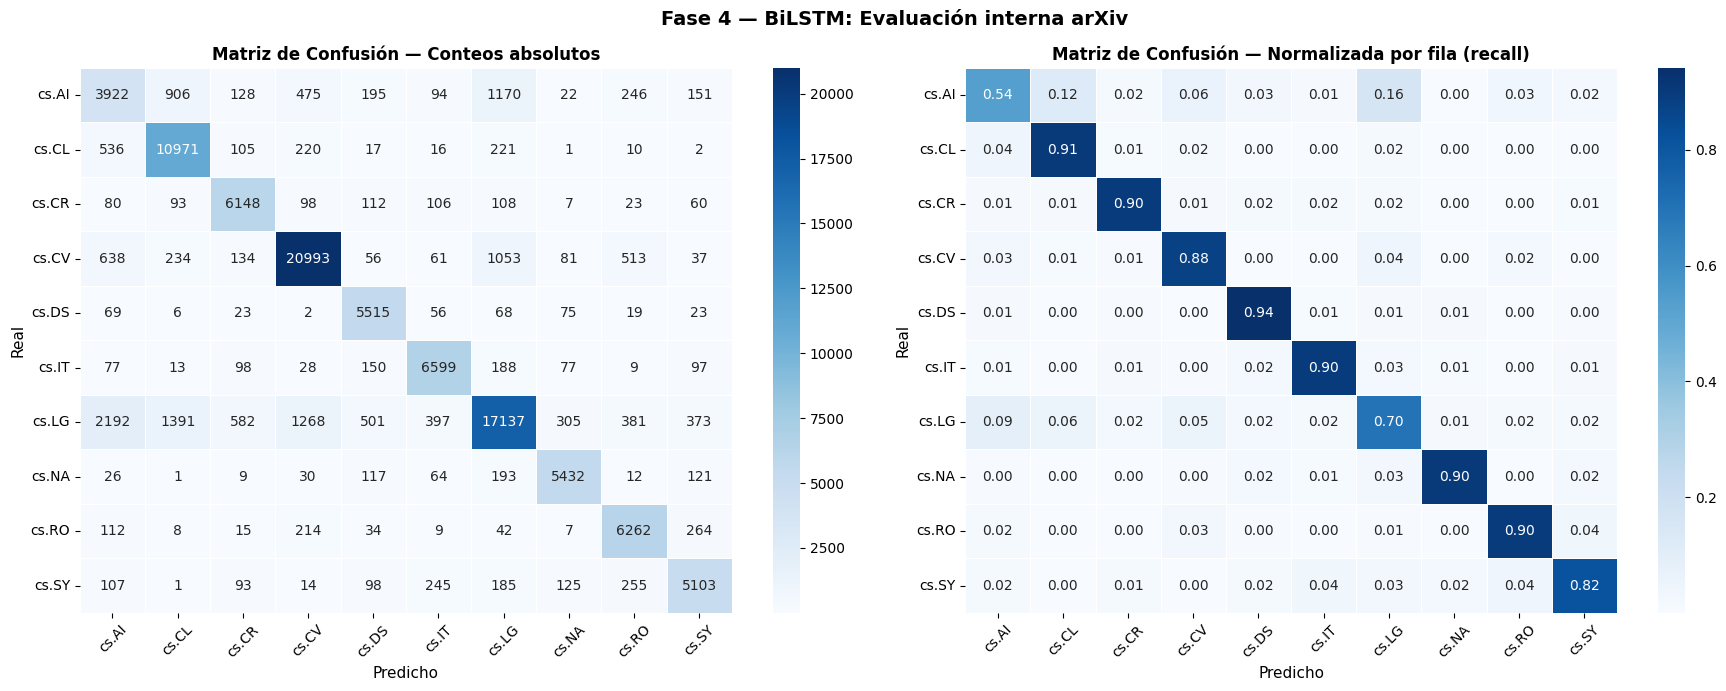

   Matriz guardada: bilstm_confusion_arxiv.png

─────────────────────────────────────────────
  Modelo                      Macro F1
─────────────────────────────────────────────
  TF-IDF + LogReg (baseline)     0.8020
  BiLSTM + FastText             0.8215
─────────────────────────────────────────────
  Diferencia                   +0.0195
─────────────────────────────────────────────


In [9]:
#  Cargar el mejor modelo guardado 
print(f"Cargando mejor modelo desde '{MODEL_SAVE_PATH}' ...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()
print("   Modelo cargado")

#  Evaluación completa sobre validación arXiv 
test_loss_final, test_f1_final, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

label_names = [idx2label[i] for i in range(NUM_CLASSES)]

print(f"\n{'='*60}")
print(f"  EVALUACIÓN — TEST INTERNO arXiv (15%)")
print(f"{'='*60}")
print(f"  Val Loss    : {test_loss_final:.4f}")
print(f"  Macro F1    : {test_f1_final:.4f}")
print(f"{'='*60}\n")
#  Classification report 
print("Classification Report por clase:")
print(classification_report(
    test_labels, test_preds,
    target_names=label_names,
    digits=4
))

#  Matriz de confusión 
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Conteos absolutos", "Normalizada por fila (recall)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=label_names, yticklabels=label_names,
        cmap="Blues", ax=ax, linewidths=0.5
    )
    ax.set_xlabel("Predicho",  fontsize=11)
    ax.set_ylabel("Real",      fontsize=11)
    ax.set_title(f"Matriz de Confusión — {title}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Fase 4 — BiLSTM: Evaluación interna arXiv", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bilstm_confusion_arxiv.png", dpi=150, bbox_inches="tight")
plt.show()
print("   Matriz guardada: bilstm_confusion_arxiv.png")

#  Tabla comparativa con baseline 
BASELINE_F1 = 0.8020
diff = test_f1_final - BASELINE_F1
sign = "+" if diff >= 0 else ""

print("\n" + "─" * 45)
print(f"  {'Modelo':<25} {'Macro F1':>10}")
print("─" * 45)
print(f"  {'TF-IDF + LogReg (baseline)':<25} {BASELINE_F1:>10.4f}")
print(f"  {'BiLSTM + FastText':<25} {test_f1_final:>10.4f}")
print("─" * 45)
print(f"  {'Diferencia':<25} {sign + f'{diff:.4f}':>10}")
print("─" * 45)